# Ensemble Learning: Diamonds Data Set
Download the Diamonds data set from https://www.kaggle.com/datasets/shivam2503/diamonds

Reference: https://www.datacamp.com/tutorial/xgboost-in-python

In [ ]:
# import piplite
# await piplite.install('xgboost')
# await piplite.install('seaborn')
import seaborn as sns
import xgboost as xgb
import pandas as pd
import numpy as np
import math
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error
warnings.filterwarnings("ignore")
diamonds = pd.read_csv("diamonds.csv")
diamonds.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Predicting Diamond Price via XGBoost Regression
Split the data into training and test set.

In [65]:
# Separate data into X (inputs) and y (target)
X, y = diamonds.drop('price', axis=1), diamonds[['price']]

# Convert categorical features (cut, color, clarity) into Pandas category
cats = X.select_dtypes(exclude=np.number).columns.tolist()
for col in cats:
   X[col] = X[col].astype('category')

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(40455, 10) (13485, 10) (40455, 1) (13485, 1)


Setup and train xgboost

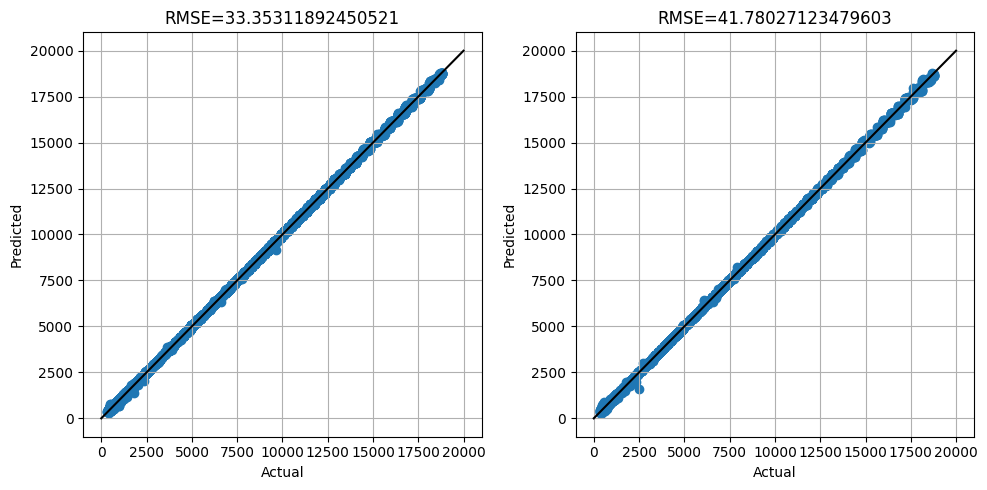

In [66]:
# Create regression matrices
dtrain_reg = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test, y_test, enable_categorical=True)

# Define hyperparameters
params = {"objective": "reg:squarederror"}
n = 100

model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n
)

y_pred_train = model.predict(dtrain_reg)
y_pred_test = model.predict(dtest_reg)
rmse_train = math.sqrt(mean_squared_error(y_pred_train, y_train))
rmse_test = math.sqrt(mean_squared_error(y_pred_test, y_test))

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2,
                               tight_layout=True,
                               figsize=(10,5))
ax1.scatter(y_train,y_pred_train)
ax1.plot(np.array([-10, 20000]),np.array([-10, 20000]),color='k')
ax1.set_xlabel('Actual')
ax1.set_ylabel('Predicted')
ax1.set_title(f"RMSE={rmse_train}")
ax1.grid()
ax2.scatter(y_test,y_pred_test)
ax2.plot(np.array([-10, 20000]),np.array([-10, 20000]),color='k')
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
ax2.set_title(f"RMSE={rmse_test}")
ax2.grid()
plt.show()

## Predicting Diamond Cut via XGBoost Classification
Different problem: Predict whether a diamond cut is ideal, premium, or good.

In [67]:
# Separate data into X (inputs) and y (target)
X, y = diamonds.drop("cut", axis=1), diamonds[['cut']]

# Encode y to numeric
y_encoded = OrdinalEncoder().fit_transform(y)

# Extract text features
cats = X.select_dtypes(exclude=np.number).columns.tolist()

# Convert to pd.Categorical
for col in cats:
   X[col] = X[col].astype('category')

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=1, stratify=y_encoded)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(40455, 10) (13485, 10) (40455, 1) (13485, 1)


Setup and train xgboost

In [ ]:
# Create classification matrices
dtrain_clf = xgb.DMatrix(X_train, y_train, enable_categorical=True)
dtest_clf = xgb.DMatrix(X_test, y_test, enable_categorical=True)

params = {"objective": "multi:softprob", "num_class": 5}
n = 1000

model = xgb.train(
   params=params,
   dtrain=dtrain_clf,
   num_boost_round=n
)

# XGBoost with cross-validation is used
results = xgb.cv(
   params, dtrain_clf,
   num_boost_round=n,
   nfold=5,
   metrics=["mlogloss", "auc", "merror"])
   
# print classification report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred_train = model.predict(dtrain_clf)
y_pred_test = model.predict(dtest_clf)

print(classification_report(y_pred_train.argmax(axis=1), y_train.flatten()))
print(classification_report(y_pred_test.argmax(axis=1), y_test.flatten()))

cfm = confusion_matrix(y_pred_train.argmax(axis=1), y_train.flatten())
cm_display = ConfusionMatrixDisplay(confusion_matrix=cfm)
cm_display.plot()
plt.title('Training Data: Confusion Matrix')

cfm = confusion_matrix(y_pred_test.argmax(axis=1), y_test.flatten())
cm_display = ConfusionMatrixDisplay(confusion_matrix=cfm)
cm_display.plot()
plt.title('Testing Data: Confusion Matrix')

In [ ]:
print(results)

     train-mlogloss-mean  train-mlogloss-std  train-auc-mean  train-auc-std  \
0               1.257324            0.000786        0.892360   5.204503e-04   
1               1.072929            0.001014        0.897256   2.292324e-04   
2               0.954850            0.001348        0.900251   7.597062e-04   
3               0.874058            0.001334        0.902809   4.463991e-04   
4               0.815702            0.001363        0.905812   7.078968e-04   
..                   ...                 ...             ...            ...   
995             0.037488            0.000428        1.000000   4.617142e-08   
996             0.037441            0.000428        1.000000   4.428677e-08   
997             0.037366            0.000425        1.000000   4.321467e-08   
998             0.037310            0.000433        1.000000   4.368765e-08   
999             0.037226            0.000440        1.000000   4.449420e-08   

     train-merror-mean  train-merror-std  test-mlog

In [71]:
print(f"Maximum Mean-AUC on Test Data: {results['test-auc-mean'].max()}")

Maximum Mean-AUC on Test Data: 0.9399628877511231
